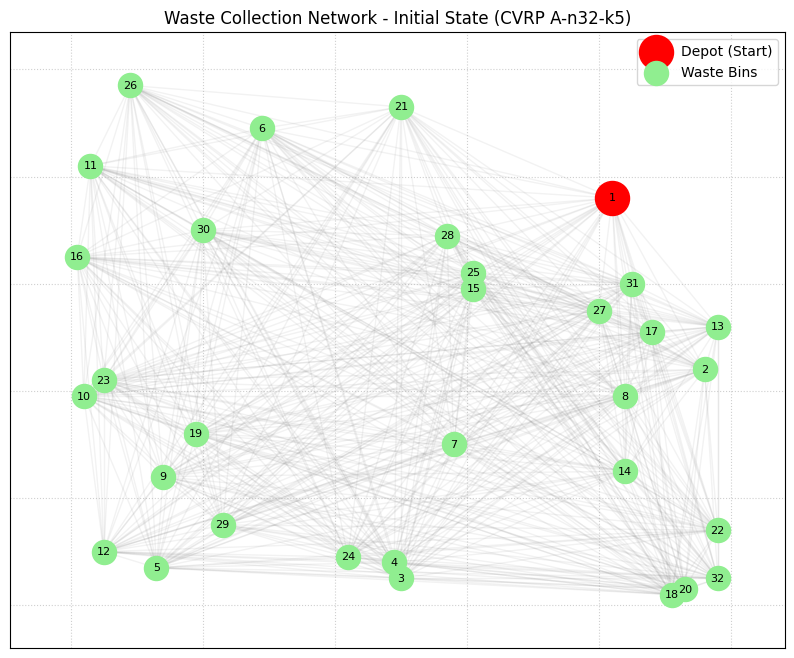

Total Nodes Processed: 32
Total Edges Created: 496


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# நீங்கள் கொடுத்த முழுமையான தரவு
vrp_data = """NAME : A-n32-k5
COMMENT : (Augerat et al, No of trucks: 5, Optimal value: 784)
TYPE : CVRP
DIMENSION : 32
EDGE_WEIGHT_TYPE : EUC_2D
CAPACITY : 100
NODE_COORD_SECTION
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 59
 16 1 65
 17 88 51
 18 91 2
 19 19 32
 20 93 3
 21 50 93
 22 98 14
 23 5 42
 24 42 9
 25 61 62
 26 9 97
 27 80 55
 28 57 69
 29 23 15
 30 20 70
 31 85 60
 32 98 5
DEMAND_SECTION
1 0
2 19
3 21
4 6
5 19
6 7
7 12
8 16
9 6
10 16
11 8
12 14
13 21
14 16
15 3
16 22
17 18
18 19
19 1
20 24
21 8
22 12
23 4
24 8
25 24
26 24
27 2
28 20
29 15
30 2
31 14
32 9
DEPOT_SECTION
 1
 -1
EOF"""

# தரவுகளைப் பிரித்தெடுத்தல்
lines = vrp_data.strip().split('\n')
nodes = {}
demands = {}

read_coords = False
read_demands = False

for line in lines:
    line = line.strip()
    if line.startswith("NODE_COORD_SECTION"):
        read_coords = True
        read_demands = False
        continue
    elif line.startswith("DEMAND_SECTION"):
        read_coords = False
        read_demands = True
        continue
    elif line.startswith("DEPOT_SECTION") or line.startswith("EOF"):
        read_demands = False
        continue

    parts = line.split()
    if read_coords and len(parts) == 3:
        nodes[int(parts[0])] = (float(parts[1]), float(parts[2]))
    elif read_demands and len(parts) == 2:
        demands[int(parts[0])] = int(parts[1])

# NetworkX வரைபடத்தை உருவாக்குதல்
G = nx.Graph()

# முனைகளை (Nodes) சேர்த்தல்
for node_id, pos in nodes.items():
    G.add_node(node_id, pos=pos, demand=demands.get(node_id, 0))

# விளிம்புகளை (Edges - யூக்ளிடியன் தூரம்) சேர்த்தல்
node_ids = list(nodes.keys())
for i in range(len(node_ids)):
    for j in range(i + 1, len(node_ids)):
        n1 = node_ids[i]
        n2 = node_ids[j]
        x1, y1 = nodes[n1]
        x2, y2 = nodes[n2]
        dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        G.add_edge(n1, n2, weight=round(dist, 2))

# வரைபடத்தைக் காட்சிப்படுத்துதல்
plt.figure(figsize=(10, 8))
pos = nx.get_node_attributes(G, 'pos')

# டிப்போ (சிவப்பு) மற்றும் குப்பைத் தொட்டிகள் (பச்சை)
depot_node = [1]
customer_nodes = [n for n in G.nodes() if n != 1]

nx.draw_networkx_nodes(G, pos, nodelist=depot_node, node_color='red', node_size=600, label='Depot (Start)')
nx.draw_networkx_nodes(G, pos, nodelist=customer_nodes, node_color='lightgreen', node_size=300, label='Waste Bins')

nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_family="sans-serif")

plt.title("Waste Collection Network - Initial State (CVRP A-n32-k5)")
plt.legend(scatterpoints=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Total Nodes Processed: {G.number_of_nodes()}")
print(f"Total Edges Created: {G.number_of_edges()}")

In [ ]:
# முதலில் OSMnx லைப்ரரியை இன்ஸ்டால் செய்ய வேண்டும் (ஏற்கெனவே இருந்தால் இது விரைவாக முடிந்துவிடும்)
!pip install osmnx networkx matplotlib

import osmnx as ox
import matplotlib.pyplot as plt

print("தஞ்சாவூர் வரைபடம் பதிவிறக்கம் ஆகிறது... சில நொடிகள் காத்திருக்கவும்...")

# தஞ்சாவூர் நகரத்தின் வாகனச் சாலைகளை மட்டும் (Drive network) பிரித்தெடுத்தல்
place_name = "Thanjavur, Tamil Nadu, India"
G = ox.graph_from_place(place_name, network_type='drive')

print(f"மொத்த முனைகள் (Nodes/Junctions): {G.number_of_nodes()}")
print(f"மொத்த சாலைகள் (Edges): {G.number_of_edges()}")

# வரைபடத்தைக் காட்சிப்படுத்துதல்
fig, ax = ox.plot_graph(G,
                        node_size=1,
                        node_color='red',
                        edge_color='#999999',
                        edge_linewidth=0.5,
                        bgcolor='white',
                        title="Thanjavur City Road Network")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.3 MB/s eta 0:00:00
தஞ்சாவூர் வரைபடம் பதிவிறக்கம் ஆகிறது... சில நொடிகள் காத்திருக்கவும்...
மொத்த முனைகள் (Nodes/Junctions): 54058
மொத்த சாலைகள் (Edges): 138273


TypeError: plot_graph() got an unexpected keyword argument 'title'

தஞ்சாவூர் வரைபடம் பதிவிறக்கம் ஆகிறது... சில நொடிகள் காத்திருக்கவும்...
மொத்த முனைகள் (Nodes/Junctions): 54058
மொத்த சாலைகள் (Edges): 138273


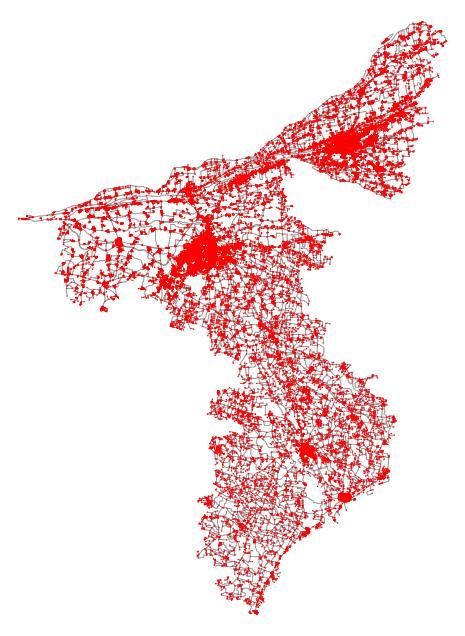

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

print("தஞ்சாவூர் வரைபடம் பதிவிறக்கம் ஆகிறது... சில நொடிகள் காத்திருக்கவும்...")

# தஞ்சாவூர் நகரத்தின் வாகனச் சாலைகளை மட்டும் (Drive network) பிரித்தெடுத்தல்
place_name = "Thanjavur, Tamil Nadu, India"
G = ox.graph_from_place(place_name, network_type='drive')

print(f"மொத்த முனைகள் (Nodes/Junctions): {G.number_of_nodes()}")
print(f"மொத்த சாலைகள் (Edges): {G.number_of_edges()}")

# title வரியை நீக்கிவிட்டு வரைபடத்தைக் காட்சிப்படுத்துதல்
fig, ax = ox.plot_graph(G,
                        node_size=1,
                        node_color='red',
                        edge_color='#999999',
                        edge_linewidth=0.5,
                        bgcolor='white')

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

print("குறிப்பிட்ட பகுதியை மட்டும் பிரித்தெடுக்கிறோம்... காத்திருக்கவும்...")

# PMIST வளாகத்தின் அட்சரேகை, தீர்க்கரேகை (Latitude, Longitude)
point = (10.7265, 79.0514)

# அந்த மையப் புள்ளியிலிருந்து 3000 மீட்டர் (3 கி.மீ) சுற்றளவுக்கு மட்டும் சாலைகளை எடுத்தல்
G_small = ox.graph_from_point(point, dist=3000, network_type='drive')

print(f"சுருக்கப்பட்ட முனைகள் (Nodes): {G_small.number_of_nodes()}")
print(f"சுருக்கப்பட்ட சாலைகள் (Edges): {G_small.number_of_edges()}")

# சிறிய வரைபடத்தைக் காட்சிப்படுத்துதல்
fig, ax = ox.plot_graph(G_small,
                        node_size=10,
                        node_color='blue',
                        edge_color='#999999',
                        bgcolor='white',
                        title="Focused Road Network (3km Radius)")

குறிப்பிட்ட பகுதியை மட்டும் பிரித்தெடுக்கிறோம்... காத்திருக்கவும்...
சுருக்கப்பட்ட முனைகள் (Nodes): 1285
சுருக்கப்பட்ட சாலைகள் (Edges): 3198


TypeError: plot_graph() got an unexpected keyword argument 'title'

குறிப்பிட்ட பகுதியை மட்டும் பிரித்தெடுக்கிறோம்... காத்திருக்கவும்...
சுருக்கப்பட்ட முனைகள் (Nodes): 1285
சுருக்கப்பட்ட சாலைகள் (Edges): 3198


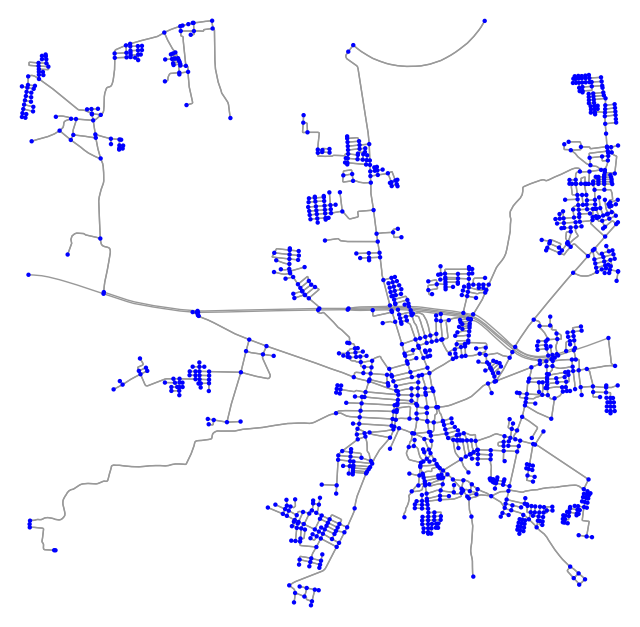

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

print("குறிப்பிட்ட பகுதியை மட்டும் பிரித்தெடுக்கிறோம்... காத்திருக்கவும்...")

# PMIST வளாகத்தின் அட்சரேகை, தீர்க்கரேகை (Latitude, Longitude)
point = (10.7265, 79.0514)

# அந்த மையப் புள்ளியிலிருந்து 3000 மீட்டர் (3 கி.மீ) சுற்றளவுக்கு மட்டும் சாலைகளை எடுத்தல்
G_small = ox.graph_from_point(point, dist=3000, network_type='drive')

print(f"சுருக்கப்பட்ட முனைகள் (Nodes): {G_small.number_of_nodes()}")
print(f"சுருக்கப்பட்ட சாலைகள் (Edges): {G_small.number_of_edges()}")

# title வரியை நீக்கிவிட்டுச் சிறிய வரைபடத்தைக் காட்சிப்படுத்துதல்
fig, ax = ox.plot_graph(G_small,
                        node_size=10,
                        node_color='blue',
                        edge_color='#999999',
                        bgcolor='white')

--- குப்பை வண்டிகளின் பயண விவரம் ---
வண்டி 1 பாதை: [1, 31, 27, 17, 13, 2, 8, 15, 30, 23, 19, 1] | ஏற்றிய குப்பை: 100/100 | தூரம்: 262.33
வண்டி 2 பாதை: [1, 25, 28, 21, 6, 26, 11, 9, 1] | ஏற்றிய குப்பை: 97/100 | தூரம்: 262.01
வண்டி 3 பாதை: [1, 14, 22, 32, 20, 18, 4, 24, 1] | ஏற்றிய குப்பை: 94/100 | தூரம்: 212.99
வண்டி 4 பாதை: [1, 7, 3, 29, 5, 12, 10, 1] | ஏற்றிய குப்பை: 97/100 | தூரம்: 245.57
வண்டி 5 பாதை: [1, 16, 1] | ஏற்றிய குப்பை: 22/100 | தூரம்: 163.49

நமது அல்காரிதமின் மொத்த தூரம்: 1146.40 (சிறந்த விடை / Optimal: 784.00)


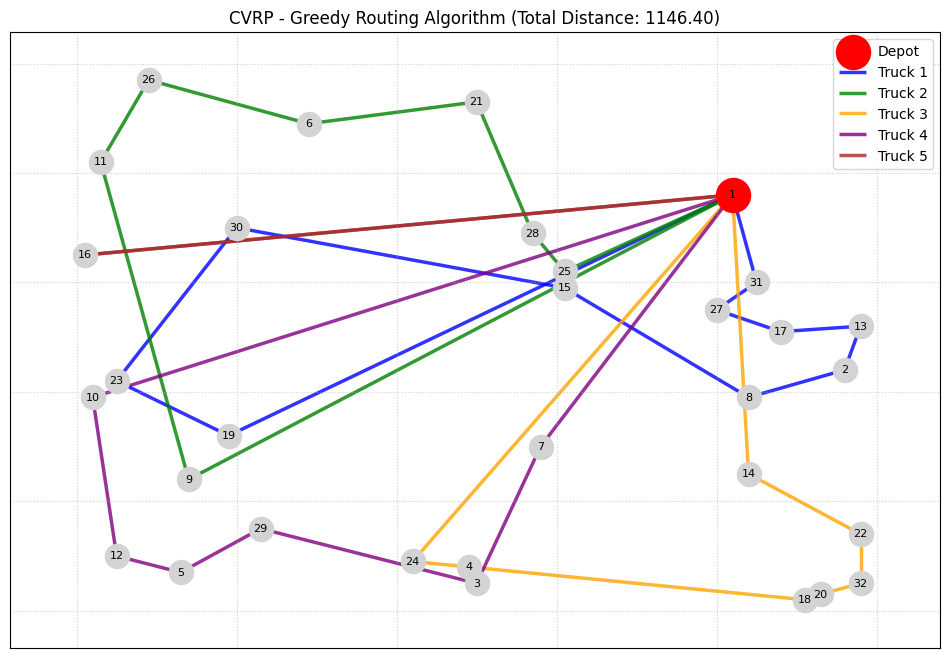

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# முழுமையான தரவு (A-n32-k5)
vrp_data = """NAME : A-n32-k5
COMMENT : (Augerat et al, No of trucks: 5, Optimal value: 784)
TYPE : CVRP
DIMENSION : 32
EDGE_WEIGHT_TYPE : EUC_2D
CAPACITY : 100
NODE_COORD_SECTION
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 59
 16 1 65
 17 88 51
 18 91 2
 19 19 32
 20 93 3
 21 50 93
 22 98 14
 23 5 42
 24 42 9
 25 61 62
 26 9 97
 27 80 55
 28 57 69
 29 23 15
 30 20 70
 31 85 60
 32 98 5
DEMAND_SECTION
1 0
2 19
3 21
4 6
5 19
6 7
7 12
8 16
9 6
10 16
11 8
12 14
13 21
14 16
15 3
16 22
17 18
18 19
19 1
20 24
21 8
22 12
23 4
24 8
25 24
26 24
27 2
28 20
29 15
30 2
31 14
32 9
DEPOT_SECTION
 1
 -1
EOF"""

# தரவுகளைப் பிரித்தெடுத்தல்
lines = vrp_data.strip().split('\n')
nodes, demands = {}, {}
read_coords, read_demands = False, False

for line in lines:
    line = line.strip()
    if line.startswith("NODE_COORD_SECTION"):
        read_coords, read_demands = True, False
        continue
    elif line.startswith("DEMAND_SECTION"):
        read_coords, read_demands = False, True
        continue
    elif line.startswith("DEPOT_SECTION") or line.startswith("EOF"):
        read_demands = False
        continue
    parts = line.split()
    if read_coords and len(parts) == 3:
        nodes[int(parts[0])] = (float(parts[1]), float(parts[2]))
    elif read_demands and len(parts) == 2:
        demands[int(parts[0])] = int(parts[1])

# தூரத்தைக் கணக்கிடும் ஃபார்முலா (Euclidean Distance)
def calc_dist(n1, n2):
    return math.sqrt((nodes[n2][0] - nodes[n1][0])**2 + (nodes[n2][1] - nodes[n1][1])**2)

# --- GREEDY ALGORITHM (அருகில் உள்ள முனையைத் தேடுதல்) ---
unvisited = set(nodes.keys())
unvisited.remove(1) # டிப்போவை நீக்குகிறோம்
routes = []
max_capacity = 100

while unvisited:
    current_node = 1
    current_load = 0
    route = [1]

    while unvisited:
        best_distance = float('inf')
        best_node = None

        # அருகில் உள்ள மற்றும் கொள்ளளவுக்குள் அடங்கும் தொட்டியைத் தேடுதல்
        for candidate in unvisited:
            if current_load + demands[candidate] <= max_capacity:
                dist = calc_dist(current_node, candidate)
                if dist < best_distance:
                    best_distance = dist
                    best_node = candidate

        if best_node is None:
            break # வண்டி நிரம்பிவிட்டது, டிப்போ திரும்ப வேண்டும்

        route.append(best_node)
        current_load += demands[best_node]
        unvisited.remove(best_node)
        current_node = best_node

    route.append(1) # டிப்போவிற்குத் திரும்புதல்
    routes.append(route)

# --- வரைபடத்தைக் காட்சிப்படுத்துதல் (Visualization & Graph Coloring) ---
G = nx.Graph()
for node_id, pos in nodes.items():
    G.add_node(node_id, pos=pos)

plt.figure(figsize=(12, 8))
pos = nx.get_node_attributes(G, 'pos')

# முனைகளை வரைதல்
nx.draw_networkx_nodes(G, pos, nodelist=[1], node_color='red', node_size=600, label='Depot')
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes() if n != 1], node_color='lightgray', node_size=300)
nx.draw_networkx_labels(G, pos, font_size=8)

# 5 வண்டிகளுக்கான தனித்தனி வண்ணங்கள்
colors = ['blue', 'green', 'orange', 'purple', 'brown']
total_distance = 0

print("--- குப்பை வண்டிகளின் பயண விவரம் ---")
for i, route in enumerate(routes):
    route_edges = [(route[j], route[j+1]) for j in range(len(route)-1)]
    color = colors[i % len(colors)]

    # பாதையை வரைதல்
    nx.draw_networkx_edges(G, pos, edgelist=route_edges, edge_color=color, width=2.5, alpha=0.8, label=f'Truck {i+1}')

    route_dist = sum(calc_dist(route[j], route[j+1]) for j in range(len(route)-1))
    total_distance += route_dist
    route_load = sum(demands[n] for n in route)
    print(f"வண்டி {i+1} பாதை: {route} | ஏற்றிய குப்பை: {route_load}/100 | தூரம்: {route_dist:.2f}")

print(f"\nநமது அல்காரிதமின் மொத்த தூரம்: {total_distance:.2f} (சிறந்த விடை / Optimal: 784.00)")

plt.title(f"CVRP - Greedy Routing Algorithm (Total Distance: {total_distance:.2f})")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

--- 2-Opt உகப்பாக்கம் செய்யப்பட்ட பயண விவரம் ---
வண்டி 1: [1, 31, 27, 17, 13, 2, 8, 19, 23, 30, 15, 1] | தூரம்: 247.40
வண்டி 2: [1, 25, 28, 9, 11, 26, 6, 21, 1] | தூரம்: 249.89
வண்டி 3: [1, 14, 22, 32, 20, 18, 4, 24, 1] | தூரம்: 212.99
வண்டி 4: [1, 7, 3, 29, 5, 12, 10, 1] | தூரம்: 245.57
வண்டி 5: [1, 16, 1] | தூரம்: 163.49

புதிய மொத்த தூரம்: 1119.34 (பழைய தூரம்: 1146.40)


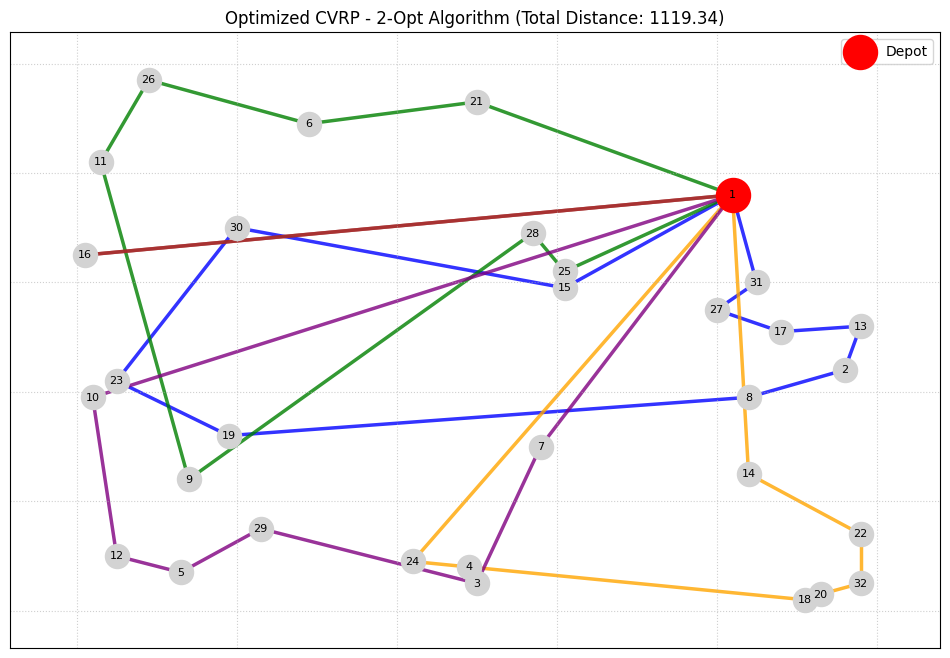

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# தரவு A-n32-k5
vrp_data = """NAME : A-n32-k5
DIMENSION : 32
CAPACITY : 100
NODE_COORD_SECTION
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 59
 16 1 65
 17 88 51
 18 91 2
 19 19 32
 20 93 3
 21 50 93
 22 98 14
 23 5 42
 24 42 9
 25 61 62
 26 9 97
 27 80 55
 28 57 69
 29 23 15
 30 20 70
 31 85 60
 32 98 5
DEMAND_SECTION
1 0
2 19
3 21
4 6
5 19
6 7
7 12
8 16
9 6
10 16
11 8
12 14
13 21
14 16
15 3
16 22
17 18
18 19
19 1
20 24
21 8
22 12
23 4
24 8
25 24
26 24
27 2
28 20
29 15
30 2
31 14
32 9
DEPOT_SECTION
 1
 -1
EOF"""

# தரவுகளைப் பிரித்தெடுத்தல்
lines = vrp_data.strip().split('\n')
nodes, demands = {}, {}
read_coords, read_demands = False, False

for line in lines:
    line = line.strip()
    if line.startswith("NODE_COORD_SECTION"): read_coords, read_demands = True, False; continue
    elif line.startswith("DEMAND_SECTION"): read_coords, read_demands = False, True; continue
    elif line.startswith("DEPOT_SECTION") or line.startswith("EOF"): read_demands = False; continue
    parts = line.split()
    if read_coords and len(parts) == 3: nodes[int(parts[0])] = (float(parts[1]), float(parts[2]))
    elif read_demands and len(parts) == 2: demands[int(parts[0])] = int(parts[1])

def calc_dist(n1, n2): return math.sqrt((nodes[n2][0] - nodes[n1][0])**2 + (nodes[n2][1] - nodes[n1][1])**2)
def route_length(route): return sum(calc_dist(route[i], route[i+1]) for i in range(len(route)-1))

# 1. Greedy Algorithm (பழைய முறை)
unvisited = set(nodes.keys()) - {1}
greedy_routes = []
while unvisited:
    curr, load, route = 1, 0, [1]
    while unvisited:
        best_dist, best_node = float('inf'), None
        for cand in unvisited:
            if load + demands[cand] <= 100:
                dist = calc_dist(curr, cand)
                if dist < best_dist: best_dist, best_node = dist, cand
        if not best_node: break
        route.append(best_node); load += demands[best_node]; unvisited.remove(best_node); curr = best_node
    route.append(1)
    greedy_routes.append(route)

# 2. 2-Opt Optimization (புதிய உகப்பாக்கம் - வெட்டும் கோடுகளை நீக்குதல்)
def two_opt(route):
    best_route = route
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                if j - i == 1: continue
                new_route = route[:]
                new_route[i:j] = route[j-1:i-1:-1] # கோடுகளை மாற்றி இணைத்தல்
                if route_length(new_route) < route_length(best_route):
                    best_route = new_route
                    improved = True
    return best_route

optimized_routes = [two_opt(r) for r in greedy_routes]

# வரைபடம் வரைதல்
G = nx.Graph()
for n, p in nodes.items(): G.add_node(n, pos=p)
plt.figure(figsize=(12, 8))
pos = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, nodelist=[1], node_color='red', node_size=600, label='Depot')
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes() if n != 1], node_color='lightgray', node_size=300)
nx.draw_networkx_labels(G, pos, font_size=8)

colors = ['blue', 'green', 'orange', 'purple', 'brown']
total_dist = 0

print("--- 2-Opt உகப்பாக்கம் செய்யப்பட்ட பயண விவரம் ---")
for i, route in enumerate(optimized_routes):
    edges = [(route[j], route[j+1]) for j in range(len(route)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors[i%len(colors)], width=2.5, alpha=0.8)
    dist = route_length(route)
    total_dist += dist
    print(f"வண்டி {i+1}: {route} | தூரம்: {dist:.2f}")

print(f"\nபுதிய மொத்த தூரம்: {total_dist:.2f} (பழைய தூரம்: 1146.40)")
plt.title(f"Optimized CVRP - 2-Opt Algorithm (Total Distance: {total_dist:.2f})")
plt.legend(); plt.grid(True, linestyle=':', alpha=0.6); plt.show()

--- 2-Opt உகப்பாக்கம் செய்யப்பட்ட பயண விவரம் ---
வண்டி 1: [1, 31, 27, 17, 13, 2, 8, 19, 23, 30, 15, 1] | தூரம்: 247.40
வண்டி 2: [1, 25, 28, 9, 11, 26, 6, 21, 1] | தூரம்: 249.89
வண்டி 3: [1, 14, 22, 32, 20, 18, 4, 24, 1] | தூரம்: 212.99
வண்டி 4: [1, 7, 3, 29, 5, 12, 10, 1] | தூரம்: 245.57
வண்டி 5: [1, 16, 1] | தூரம்: 163.49

புதிய மொத்த தூரம்: 1119.34 (பழைய தூரம்: 1146.40)


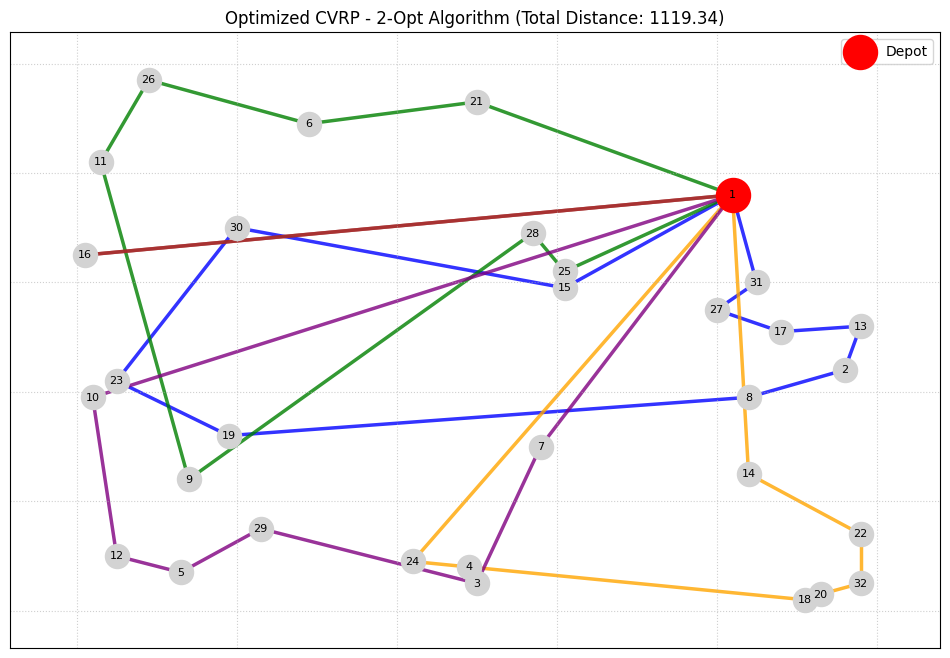

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# தரவு A-n32-k5
vrp_data = """NAME : A-n32-k5
DIMENSION : 32
CAPACITY : 100
NODE_COORD_SECTION
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 59
 16 1 65
 17 88 51
 18 91 2
 19 19 32
 20 93 3
 21 50 93
 22 98 14
 23 5 42
 24 42 9
 25 61 62
 26 9 97
 27 80 55
 28 57 69
 29 23 15
 30 20 70
 31 85 60
 32 98 5
DEMAND_SECTION
1 0
2 19
3 21
4 6
5 19
6 7
7 12
8 16
9 6
10 16
11 8
12 14
13 21
14 16
15 3
16 22
17 18
18 19
19 1
20 24
21 8
22 12
23 4
24 8
25 24
26 24
27 2
28 20
29 15
30 2
31 14
32 9
DEPOT_SECTION
 1
 -1
EOF"""

# தரவுகளைப் பிரித்தெடுத்தல்
lines = vrp_data.strip().split('\n')
nodes, demands = {}, {}
read_coords, read_demands = False, False

for line in lines:
    line = line.strip()
    if line.startswith("NODE_COORD_SECTION"): read_coords, read_demands = True, False; continue
    elif line.startswith("DEMAND_SECTION"): read_coords, read_demands = False, True; continue
    elif line.startswith("DEPOT_SECTION") or line.startswith("EOF"): read_demands = False; continue
    parts = line.split()
    if read_coords and len(parts) == 3: nodes[int(parts[0])] = (float(parts[1]), float(parts[2]))
    elif read_demands and len(parts) == 2: demands[int(parts[0])] = int(parts[1])

def calc_dist(n1, n2): return math.sqrt((nodes[n2][0] - nodes[n1][0])**2 + (nodes[n2][1] - nodes[n1][1])**2)
def route_length(route): return sum(calc_dist(route[i], route[i+1]) for i in range(len(route)-1))

# 1. Greedy Algorithm (பழைய முறை)
unvisited = set(nodes.keys()) - {1}
greedy_routes = []
while unvisited:
    curr, load, route = 1, 0, [1]
    while unvisited:
        best_dist, best_node = float('inf'), None
        for cand in unvisited:
            if load + demands[cand] <= 100:
                dist = calc_dist(curr, cand)
                if dist < best_dist: best_dist, best_node = dist, cand
        if not best_node: break
        route.append(best_node); load += demands[best_node]; unvisited.remove(best_node); curr = best_node
    route.append(1)
    greedy_routes.append(route)

# 2. 2-Opt Optimization (புதிய உகப்பாக்கம் - வெட்டும் கோடுகளை நீக்குதல்)
def two_opt(route):
    best_route = route
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                if j - i == 1: continue
                new_route = route[:]
                new_route[i:j] = route[j-1:i-1:-1] # கோடுகளை மாற்றி இணைத்தல்
                if route_length(new_route) < route_length(best_route):
                    best_route = new_route
                    improved = True
    return best_route

optimized_routes = [two_opt(r) for r in greedy_routes]

# வரைபடம் வரைதல்
G = nx.Graph()
for n, p in nodes.items(): G.add_node(n, pos=p)
plt.figure(figsize=(12, 8))
pos = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, nodelist=[1], node_color='red', node_size=600, label='Depot')
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes() if n != 1], node_color='lightgray', node_size=300)
nx.draw_networkx_labels(G, pos, font_size=8)

colors = ['blue', 'green', 'orange', 'purple', 'brown']
total_dist = 0

print("--- 2-Opt உகப்பாக்கம் செய்யப்பட்ட பயண விவரம் ---")
for i, route in enumerate(optimized_routes):
    edges = [(route[j], route[j+1]) for j in range(len(route)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors[i%len(colors)], width=2.5, alpha=0.8)
    dist = route_length(route)
    total_dist += dist
    print(f"வண்டி {i+1}: {route} | தூரம்: {dist:.2f}")

print(f"\nபுதிய மொத்த தூரம்: {total_dist:.2f} (பழைய தூரம்: 1146.40)")
plt.title(f"Optimized CVRP - 2-Opt Algorithm (Total Distance: {total_dist:.2f})")
plt.legend(); plt.grid(True, linestyle=':', alpha=0.6); plt.show()

--- Sweep + 2-Opt கலப்பின அல்காரிதமின் பயண விவரம் ---
மண்டலம் 1 வண்டி: [1, 30, 16, 28, 23, 10, 9, 19, 25, 15, 1] | ஏற்றிய குப்பை: 98/100 | தூரம்: 311.19
மண்டலம் 2 வண்டி: [1, 12, 5, 29, 24, 3, 4, 7, 27, 1] | ஏற்றிய குப்பை: 97/100 | தூரம்: 232.96
மண்டலம் 3 வண்டி: [1, 14, 8, 18, 20, 32, 31, 1] | ஏற்றிய குப்பை: 98/100 | தூரம்: 183.11
மண்டலம் 4 வண்டி: [1, 13, 2, 22, 17, 21, 1] | ஏற்றிய குப்பை: 78/100 | தூரம்: 198.36
மண்டலம் 5 வண்டி: [1, 6, 26, 11, 1] | ஏற்றிய குப்பை: 39/100 | தூரம்: 171.49

கலப்பின மாடலின் புதிய மொத்த தூரம்: 1097.12 (பழைய 2-Opt தூரம்: 1119.34)


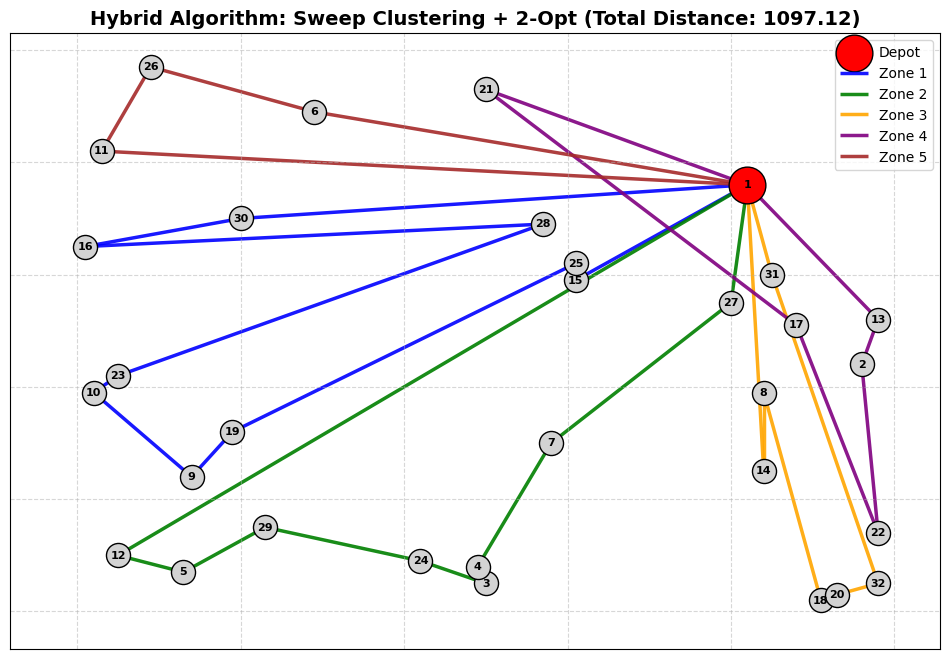

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# தரவு A-n32-k5
vrp_data = """NAME : A-n32-k5
DIMENSION : 32
CAPACITY : 100
NODE_COORD_SECTION
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 59
 16 1 65
 17 88 51
 18 91 2
 19 19 32
 20 93 3
 21 50 93
 22 98 14
 23 5 42
 24 42 9
 25 61 62
 26 9 97
 27 80 55
 28 57 69
 29 23 15
 30 20 70
 31 85 60
 32 98 5
DEMAND_SECTION
1 0
2 19
3 21
4 6
5 19
6 7
7 12
8 16
9 6
10 16
11 8
12 14
13 21
14 16
15 3
16 22
17 18
18 19
19 1
20 24
21 8
22 12
23 4
24 8
25 24
26 24
27 2
28 20
29 15
30 2
31 14
32 9
DEPOT_SECTION
 1
 -1
EOF"""

# தரவுகளைப் பிரித்தெடுத்தல்
lines = vrp_data.strip().split('\n')
nodes, demands = {}, {}
read_coords, read_demands = False, False

for line in lines:
    line = line.strip()
    if line.startswith("NODE_COORD_SECTION"): read_coords, read_demands = True, False; continue
    elif line.startswith("DEMAND_SECTION"): read_coords, read_demands = False, True; continue
    elif line.startswith("DEPOT_SECTION") or line.startswith("EOF"): read_demands = False; continue
    parts = line.split()
    if read_coords and len(parts) == 3: nodes[int(parts[0])] = (float(parts[1]), float(parts[2]))
    elif read_demands and len(parts) == 2: demands[int(parts[0])] = int(parts[1])

def calc_dist(n1, n2): return math.sqrt((nodes[n2][0] - nodes[n1][0])**2 + (nodes[n2][1] - nodes[n1][1])**2)
def route_length(route): return sum(calc_dist(route[i], route[i+1]) for i in range(len(route)-1))

# --- புதிய கலப்பின அல்காரிதம் (Hybrid: Sweep + 2-Opt) ---

# 1. Sweep Clustering (கோண அடிப்படையில் பிரித்தல்)
depot_x, depot_y = nodes[1]
angles = {}
for n in nodes:
    if n != 1:
        # டிப்போவை மையமாக வைத்து ஒவ்வொரு முனையின் கோணத்தைக் (Angle) கணக்கிடுதல்
        angle = math.atan2(nodes[n][1] - depot_y, nodes[n][0] - depot_x)
        angles[n] = angle

# கோணத்தின் அடிப்படையில் வரிசைப்படுத்துதல்
sorted_nodes = sorted(angles.keys(), key=lambda x: angles[x])

clusters = []
current_cluster = []
current_load = 0

for node in sorted_nodes:
    if current_load + demands[node] <= 100:
        current_cluster.append(node)
        current_load += demands[node]
    else:
        clusters.append(current_cluster)
        current_cluster = [node]
        current_load = demands[node]
if current_cluster:
    clusters.append(current_cluster)

# 2. 2-Opt Optimization (ஒவ்வொரு மண்டலத்திற்குள்ளும் பாதையை உகப்பாக்கம் செய்தல்)
def two_opt(route):
    best_route = route
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                if j - i == 1: continue
                new_route = route[:]
                new_route[i:j] = route[j-1:i-1:-1]
                if route_length(new_route) < route_length(best_route):
                    best_route = new_route
                    improved = True
    return best_route

final_routes = []
for cluster in clusters:
    # ஆரம்பப் பாதை: டிப்போ -> முனைகள் -> டிப்போ
    initial_route = [1] + cluster + [1]
    optimized_route = two_opt(initial_route)
    final_routes.append(optimized_route)

# --- வரைபடம் வரைதல் ---
G = nx.Graph()
for n, p in nodes.items(): G.add_node(n, pos=p)
plt.figure(figsize=(12, 8))
pos = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, nodelist=[1], node_color='red', node_size=700, label='Depot', edgecolors='black')
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes() if n != 1], node_color='lightgray', node_size=300, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

colors = ['blue', 'green', 'orange', 'purple', 'brown']
total_dist = 0

print("--- Sweep + 2-Opt கலப்பின அல்காரிதமின் பயண விவரம் ---")
for i, route in enumerate(final_routes):
    edges = [(route[j], route[j+1]) for j in range(len(route)-1)]
    color = colors[i % len(colors)]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=color, width=2.5, alpha=0.9, label=f'Zone {i+1}')

    dist = route_length(route)
    total_dist += dist
    load = sum(demands[n] for n in route if n != 1)
    print(f"மண்டலம் {i+1} வண்டி: {route} | ஏற்றிய குப்பை: {load}/100 | தூரம்: {dist:.2f}")

print(f"\nகலப்பின மாடலின் புதிய மொத்த தூரம்: {total_dist:.2f} (பழைய 2-Opt தூரம்: 1119.34)")

plt.title(f"Hybrid Algorithm: Sweep Clustering + 2-Opt (Total Distance: {total_dist:.2f})", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import math
import random

# Install osmnx if not already installed
!pip install osmnx

print("PMIST வளாகத்தைச் சுற்றியுள்ள நிஜ வரைபடத்தைப் பதிவிறக்குகிறோம்... சற்று காத்திருக்கவும்...")
# PMIST அட்சரேகை, தீர்க்கரேகை
point = (10.7301521, 79.0688749)
# கணக்கீட்டு வேகத்திற்காக 2 கிலோமீட்டர் சுற்றளவை மட்டும் எடுக்கிறோம்
G = ox.graph_from_point(point, dist=2000, network_type='drive')

all_nodes = list(G.nodes())

# 1 டிப்போ (Depot) மற்றும் 20 குப்பைத் தொட்டிகளை (Bins) தேர்ந்தெடுத்தல்
depot = all_nodes[0]
random.seed(42) # அல்காரிதம் மாறாமல் இருக்க
bins = random.sample(all_nodes[1:], 20)
nodes_list = [depot] + bins

# ஒவ்வொரு தொட்டிக்கும் 10 முதல் 30 கிலோ வரை குப்பையை (Demand) உருவாக்குதல்
demands = {depot: 0}
for b in bins:
    demands[b] = random.randint(10, 30)

print("சாலை வழியான தூரங்களைக் கணக்கிடுகிறோம் (Road Network Distance Matrix)...")
dist_matrix = {}
for start in nodes_list:
    dist_matrix[start] = {}
    # நேர்க்கோட்டிற்குப் பதிலாக, நிஜச் சாலை வழியான தூரத்தைக் கணக்கிடுதல் (Dijkstra's Path)
    lengths = nx.single_source_dijkstra_path_length(G, start, weight='length')
    for end in nodes_list:
        dist_matrix[start][end] = lengths.get(end, float('inf'))

# --- கலப்பின அல்காரிதம் (Hybrid: Sweep + 2-Opt) ---
# 1. Sweep Clustering (மண்டலங்களாகப் பிரித்தல்)
depot_y = G.nodes[depot]['y']
depot_x = G.nodes[depot]['x']
angles = {}
for n in bins:
    angles[n] = math.atan2(G.nodes[n]['y'] - depot_y, G.nodes[n]['x'] - depot_x)

sorted_bins = sorted(angles.keys(), key=lambda n: angles[n])
clusters, curr_cluster, curr_load = [], [], 0

for b in sorted_bins:
    if curr_load + demands[b] <= 100:
        curr_cluster.append(b)
        curr_load += demands[b]
    else:
        clusters.append(curr_cluster)
        curr_cluster = [b]
        curr_load = demands[b]
if curr_cluster:
    clusters.append(curr_cluster)

# 2. 2-Opt Optimization (பாதையைச் சீரமைத்தல்)
def route_length(route):
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

def two_opt(route):
    best_route = route
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                if j - i == 1: continue
                new_route = route[:]
                new_route[i:j] = route[j-1:i-1:-1]
                if route_length(new_route) < route_length(best_route):
                    best_route = new_route
                    improved = True
    return best_route

final_routes_nodes = []
for cluster in clusters:
    initial_route = [depot] + cluster + [depot]
    final_routes_nodes.append(two_opt(initial_route))

# --- நிஜ சாலைகளுக்கான பாதையை (Road Map Path) உருவாக்குதல் ---
road_routes = []
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'cyan']
route_colors = []

print("\n--- நிஜச் சாலைகளில் வண்டிகளின் பயண விவரம் ---")
for i, route in enumerate(final_routes_nodes):
    full_path = []
    # இரண்டு தொட்டிகளுக்கு இடையிலான உண்மையான சாலைப் பாதையைக் கண்டுபிடித்தல்
    for j in range(len(route)-1):
        path = nx.shortest_path(G, route[j], route[j+1], weight='length')
        if j > 0: path = path[1:] # முனைகள் மீண்டும் வருவதைத் தவிர்க்க
        full_path.extend(path)

    road_routes.append(full_path)
    route_colors.append(colors[i % len(colors)])

    dist = route_length(route)
    load = sum(demands[n] for n in route if n != depot)
    print(f"மண்டலம் {i+1} வண்டி | ஏற்றிய குப்பை: {load}/100 | தூரம்: {dist:.2f} மீட்டர்கள்")

# வரைபடம் வரைதல்
fig, ax = ox.plot_graph_routes(G, road_routes, route_colors=route_colors, route_linewidth=4, node_size=0, bgcolor='white', show=False, close=False)

# டிப்போ (சிவப்பு) மற்றும் தொட்டிகளை (கறுப்பு) வரைதல்
ax.scatter(depot_x, depot_y, c='red', s=300, zorder=5, label='Depot (Start)', edgecolors='black')
for b in bins:
    ax.scatter(G.nodes[b]['x'], G.nodes[b]['y'], c='black', s=60, zorder=5)

plt.title("PMIST Campus Real-Road Waste Collection (Hybrid Algorithm)", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'osmnx'

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import math
import random

# Install osmnx if not already installed
# !pip install osmnx

print("PMIST வளாகத்தைச் சுற்றியுள்ள நிஜ வரைபடத்தைப் பதிவிறக்குகிறோம்... சற்று காத்திருக்கவும்...")
# PMIST அட்சரேகை, தீர்க்கரேகை
point = (10.7301521, 79.0688749)
# கணக்கீட்டு வேகத்திற்காக 2 கிலோமீட்டர் சுற்றளவை மட்டும் எடுக்கிறோம்
G = ox.graph_from_point(point, dist=2000, network_type='drive')

all_nodes = list(G.nodes())

# 1 டிப்போ (Depot) மற்றும் 20 குப்பைத் தொட்டிகளை (Bins) தேர்ந்தெடுத்தல்
depot = all_nodes[0]
random.seed(42) # அல்காரிதம் மாறாமல் இருக்க
bins = random.sample(all_nodes[1:], 20)
nodes_list = [depot] + bins

# ஒவ்வொரு தொட்டிக்கும் 10 முதல் 30 கிலோ வரை குப்பையை (Demand) உருவாக்குதல்
demands = {depot: 0}
for b in bins:
    demands[b] = random.randint(10, 30)

print("சாலை வழியான தூரங்களைக் கணக்கிடுகிறோம் (Road Network Distance Matrix)...")
dist_matrix = {}
for start in nodes_list:
    dist_matrix[start] = {}
    # நேர்க்கோட்டிற்குப் பதிலாக, நிஜச் சாலை வழியான தூரத்தைக் கணக்கிடுதல் (Dijkstra's Path)
    lengths = nx.single_source_dijkstra_path_length(G, start, weight='length')
    for end in nodes_list:
        dist_matrix[start][end] = lengths.get(end, float('inf'))

# --- கலப்பின அல்காரிதம் (Hybrid: Sweep + 2-Opt) ---
# 1. Sweep Clustering (மண்டலங்களாகப் பிரித்தல்)
depot_y = G.nodes[depot]['y']
depot_x = G.nodes[depot]['x']
angles = {}
for n in bins:
    angles[n] = math.atan2(G.nodes[n]['y'] - depot_y, G.nodes[n]['x'] - depot_x)

sorted_bins = sorted(angles.keys(), key=lambda n: angles[n])
clusters, curr_cluster, curr_load = [], [], 0

for b in sorted_bins:
    if curr_load + demands[b] <= 100:
        curr_cluster.append(b)
        curr_load += demands[b]
    else:
        clusters.append(curr_cluster)
        curr_cluster = [b]
        curr_load = demands[b]
if curr_cluster:
    clusters.append(curr_cluster)

# 2. 2-Opt Optimization (பாதையைச் சீரமைத்தல்)
def route_length(route):
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

def two_opt(route):
    best_route = route
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                if j - i == 1: continue
                new_route = route[:]
                new_route[i:j] = route[j-1:i-1:-1]
                if route_length(new_route) < route_length(best_route):
                    best_route = new_route
                    improved = True
    return best_route

final_routes_nodes = []
for cluster in clusters:
    initial_route = [depot] + cluster + [depot]
    final_routes_nodes.append(two_opt(initial_route))

# --- நிஜ சாலைகளுக்கான பாதையை (Road Map Path) உருவாக்குதல் ---
road_routes = []
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'cyan']
route_colors = []

print("\n--- நிஜச் சாலைகளில் வண்டிகளின் பயண விவரம் ---")
for i, route in enumerate(final_routes_nodes):
    full_path = []
    # இரண்டு தொட்டிகளுக்கு இடையிலான உண்மையான சாலைப் பாதையைக் கண்டுபிடித்தல்
    for j in range(len(route)-1):
        path = nx.shortest_path(G, route[j], route[j+1], weight='length')
        if j > 0: path = path[1:] # முனைகள் மீண்டும் வருவதைத் தவிர்க்க
        full_path.extend(path)

    road_routes.append(full_path)
    route_colors.append(colors[i % len(colors)])

    dist = route_length(route)
    load = sum(demands[n] for n in route if n != depot)
    print(f"மண்டலம் {i+1} வண்டி | ஏற்றிய குப்பை: {load}/100 | தூரம்: {dist:.2f} மீட்டர்கள்")

# வரைபடம் வரைதல்
fig, ax = ox.plot_graph_routes(G, road_routes, route_colors=route_colors, route_linewidth=4, node_size=0, bgcolor='white', show=False, close=False)

# டிப்போ (சிவப்பு) மற்றும் தொட்டிகளை (கறுப்பு) வரைதல்
ax.scatter(depot_x, depot_y, c='red', s=300, zorder=5, label='Depot (Start)', edgecolors='black')
for b in bins:
    ax.scatter(G.nodes[b]['x'], G.nodes[b]['y'], c='black', s=60, zorder=5)

plt.title("PMIST Campus Real-Road Waste Collection (Hybrid Algorithm)", fontsize=14, fontweight='bold')
plt.legend()

# --- கட்டுரையில் இணைப்பதற்கான PDF ஃபைலாக சேமித்தல் ---
plt.savefig("pmist_map.pdf", format="pdf", bbox_inches="tight", dpi=300)
print("\nவரைபடம் 'pmist_map.pdf' என்ற பெயரில் வெற்றிகரமாக சேமிக்கப்பட்டது! இடதுபுறம் உள்ள Files பகுதியில் டவுன்லோட் செய்து கொள்ளலாம்.")

# திரையில் காட்டுதல்
plt.show()

ModuleNotFoundError: No module named 'osmnx'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.8 MB/s eta 0:00:00
PMIST வளாகத்தைச் சுற்றியுள்ள நிஜ வரைபடத்தைப் பதிவிறக்குகிறோம்... சற்று காத்திருக்கவும்...
சாலை வழியான தூரங்களைக் கணக்கிடுகிறோம் (Road Network Distance Matrix)...

--- நிஜச் சாலைகளில் வண்டிகளின் பயண விவரம் ---
மண்டலம் 1 வண்டி | ஏற்றிய குப்பை: 97/100 | தூரம்: 9773.68 மீட்டர்கள்
மண்டலம் 2 வண்டி | ஏற்றிய குப்பை: 87/100 | தூரம்: 9563.87 மீட்டர்கள்
மண்டலம் 3 வண்டி | ஏற்றிய குப்பை: 89/100 | தூரம்: 4790.41 மீட்டர்கள்
மண்டலம் 4 வண்டி | ஏற்றிய குப்பை: 87/100 | தூரம்: 11985.92 மீட்டர்கள்

வரைபடம் 'pmist_map.pdf' என்ற பெயரில் வெற்றிகரமாக சேமிக்கப்பட்டது! இடதுபுறம் உள்ள Files பகுதியில் டவுன்லோட் செய்து கொள்ளலாம்.


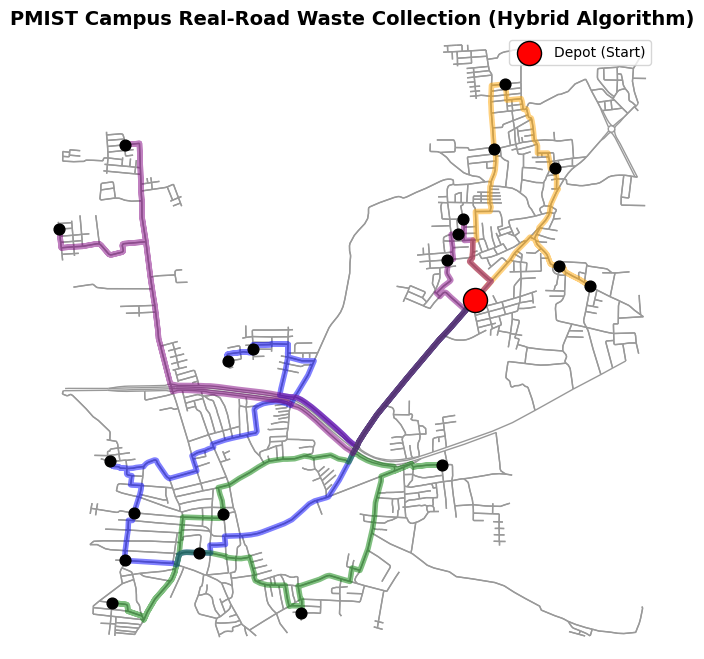

In [ ]:
!pip install osmnx

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import math
import random

print("PMIST வளாகத்தைச் சுற்றியுள்ள நிஜ வரைபடத்தைப் பதிவிறக்குகிறோம்... சற்று காத்திருக்கவும்...")
# PMIST அட்சரேகை, தீர்க்கரேகை
point = (10.7301521, 79.0688749)
# கணக்கீட்டு வேகத்திற்காக 2 கிலோமீட்டர் சுற்றளவை மட்டும் எடுக்கிறோம்
G = ox.graph_from_point(point, dist=2000, network_type='drive')

all_nodes = list(G.nodes())

# 1 டிப்போ (Depot) மற்றும் 20 குப்பைத் தொட்டிகளை (Bins) தேர்ந்தெடுத்தல்
depot = all_nodes[0]
random.seed(42) # அல்காரிதம் மாறாமல் இருக்க
bins = random.sample(all_nodes[1:], 20)
nodes_list = [depot] + bins

# ஒவ்வொரு தொட்டிக்கும் 10 முதல் 30 கிலோ வரை குப்பையை (Demand) உருவாக்குதல்
demands = {depot: 0}
for b in bins:
    demands[b] = random.randint(10, 30)

print("சாலை வழியான தூரங்களைக் கணக்கிடுகிறோம் (Road Network Distance Matrix)...")
dist_matrix = {}
for start in nodes_list:
    dist_matrix[start] = {}
    # நேர்க்கோட்டிற்குப் பதிலாக, நிஜச் சாலை வழியான தூரத்தைக் கணக்கிடுதல் (Dijkstra's Path)
    lengths = nx.single_source_dijkstra_path_length(G, start, weight='length')
    for end in nodes_list:
        dist_matrix[start][end] = lengths.get(end, float('inf'))

# --- கலப்பின அல்காரிதம் (Hybrid: Sweep + 2-Opt) ---
# 1. Sweep Clustering (மண்டலங்களாகப் பிரித்தல்)
depot_y = G.nodes[depot]['y']
depot_x = G.nodes[depot]['x']
angles = {}
for n in bins:
    angles[n] = math.atan2(G.nodes[n]['y'] - depot_y, G.nodes[n]['x'] - depot_x)

sorted_bins = sorted(angles.keys(), key=lambda n: angles[n])
clusters, curr_cluster, curr_load = [], [], 0

for b in sorted_bins:
    if curr_load + demands[b] <= 100:
        curr_cluster.append(b)
        curr_load += demands[b]
    else:
        clusters.append(curr_cluster)
        curr_cluster = [b]
        curr_load = demands[b]
if curr_cluster:
    clusters.append(curr_cluster)

# 2. 2-Opt Optimization (பாதையைச் சீரமைத்தல்)
def route_length(route):
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

def two_opt(route):
    best_route = route
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                if j - i == 1: continue
                new_route = route[:]
                new_route[i:j] = route[j-1:i-1:-1]
                if route_length(new_route) < route_length(best_route):
                    best_route = new_route
                    improved = True
    return best_route

final_routes_nodes = []
for cluster in clusters:
    initial_route = [depot] + cluster + [depot]
    final_routes_nodes.append(two_opt(initial_route))

# --- நிஜ சாலைகளுக்கான பாதையை (Road Map Path) உருவாக்குதல் ---
road_routes = []
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'cyan']
route_colors = []

print("\n--- நிஜச் சாலைகளில் வண்டிகளின் பயண விவரம் ---")
for i, route in enumerate(final_routes_nodes):
    full_path = []
    # இரண்டு தொட்டிகளுக்கு இடையிலான உண்மையான சாலைப் பாதையைக் கண்டுபிடித்தல்
    for j in range(len(route)-1):
        path = nx.shortest_path(G, route[j], route[j+1], weight='length')
        if j > 0: path = path[1:] # முனைகள் மீண்டும் வருவதைத் தவிர்க்க
        full_path.extend(path)

    road_routes.append(full_path)
    route_colors.append(colors[i % len(colors)])

    dist = route_length(route)
    load = sum(demands[n] for n in route if n != depot)
    print(f"மண்டலம் {i+1} வண்டி | ஏற்றிய குப்பை: {load}/100 | தூரம்: {dist:.2f} மீட்டர்கள்")

# வரைபடம் வரைதல்
fig, ax = ox.plot_graph_routes(G, road_routes, route_colors=route_colors, route_linewidth=4, node_size=0, bgcolor='white', show=False, close=False)

# டிப்போ (சிவப்பு) மற்றும் தொட்டிகளை (கறுப்பு) வரைதல்
ax.scatter(depot_x, depot_y, c='red', s=300, zorder=5, label='Depot (Start)', edgecolors='black')
for b in bins:
    ax.scatter(G.nodes[b]['x'], G.nodes[b]['y'], c='black', s=60, zorder=5)

plt.title("PMIST Campus Real-Road Waste Collection (Hybrid Algorithm)", fontsize=14, fontweight='bold')
plt.legend()

# --- கட்டுரையில் இணைப்பதற்கான PDF ஃபைலாக சேமித்தல் ---
plt.savefig("pmist_map.pdf", format="pdf", bbox_inches="tight", dpi=300)
print("\nவரைபடம் 'pmist_map.pdf' என்ற பெயரில் வெற்றிகரமாக சேமிக்கப்பட்டது! இடதுபுறம் உள்ள Files பகுதியில் டவுன்லோட் செய்து கொள்ளலாம்.")

# திரையில் காட்டுதல்
plt.show()